In [1]:
#Importing required libraries
import numpy as np 
import pandas as pd
import zipfile
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import ResNet50, MobileNetV2, EfficientNetB0
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficient_preprocess
from tensorflow.keras.applications.mobilenet import preprocess_input as mobilenet_preprocess
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report,f1_score,confusion_matrix,accuracy_score,precision_score,recall_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Setting the working directory
setwd = "D:/Sathish/AIML/Garbage Classification"

In [3]:
#Extracting the dataset zip folder
zip_path = "C:/Users/midst/Downloads/archive.zip"
extract_path = "Datasets"
with zipfile.ZipFile(zip_path,'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Dataset extracted to:",extract_path)

Dataset extracted to: Datasets


In [4]:
#Importing all the images dataset
data = tf.keras.utils.image_dataset_from_directory("Datasets/Garbage classification/Garbage classification",image_size=(224,224),shuffle=True,batch_size=None)
#Exploratory Data Analysis
print(len(data),data.class_names)

Found 2527 files belonging to 6 classes.
2527 ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


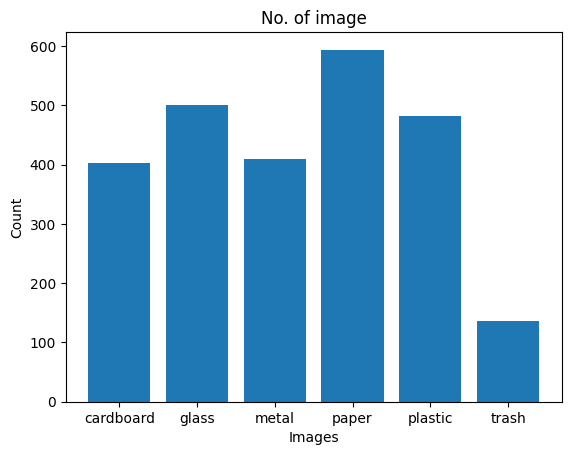

In [5]:
#Visualize the number of images per class
counts = {name: 0 for name in data.class_names}
for _,label in data:
    counts[data.class_names[label.numpy()]] += 1

plt.bar(counts.keys(),counts.values())
plt.xlabel('Images')
plt.ylabel('Count')
plt.title('No. of image')
plt.show()

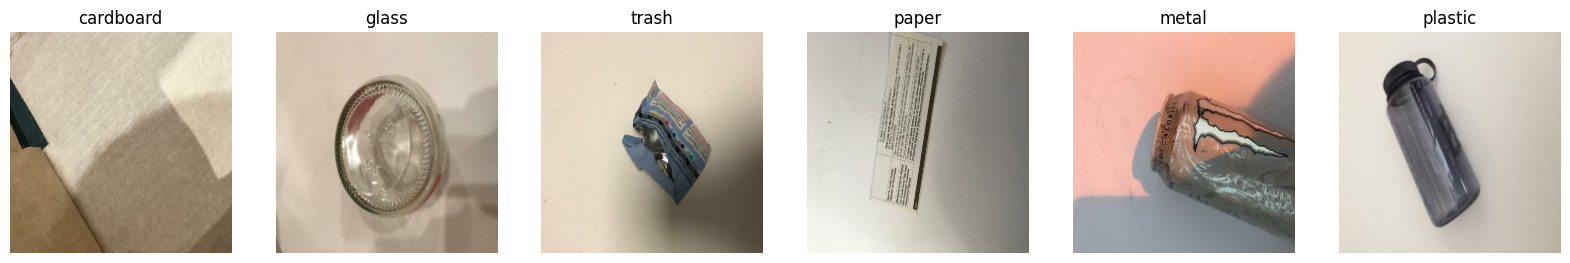

In [6]:
#Show example images from each category
examples = {}
class_names = data.class_names
#To iterate through dataset untill we collect one example for each class
for img,label in data.take(100):
        lbl = label.numpy()
        class_name = class_names[lbl]
        if class_name not in examples:
                examples[class_name] = img
        if len(examples) == len(class_names):
            break
plt.figure(figsize=(20,6))
for i, (class_name,img) in enumerate(examples.items()):
       ax = plt.subplot(1,len(examples),i+1)
       plt.imshow(img.numpy().astype('uint8'))
       plt.title(class_name)
       plt.axis('off')
plt.show()

In [7]:
#Normalize each pixel values form 0-255 to 0-1
normalization_layer = tf.keras.layers.Rescaling(1./255)
#the reason why here 1./255 rather 1/255 is anyway the result is going to be float so explicitly we are giving 1. as float so a pixel value is multiplied with 1./255
data_1 = data.map(lambda x,y: ((normalization_layer(x)),y))

C:\Users\midst\AppData\Local\Temp\ipykernel_31024\3508213849.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


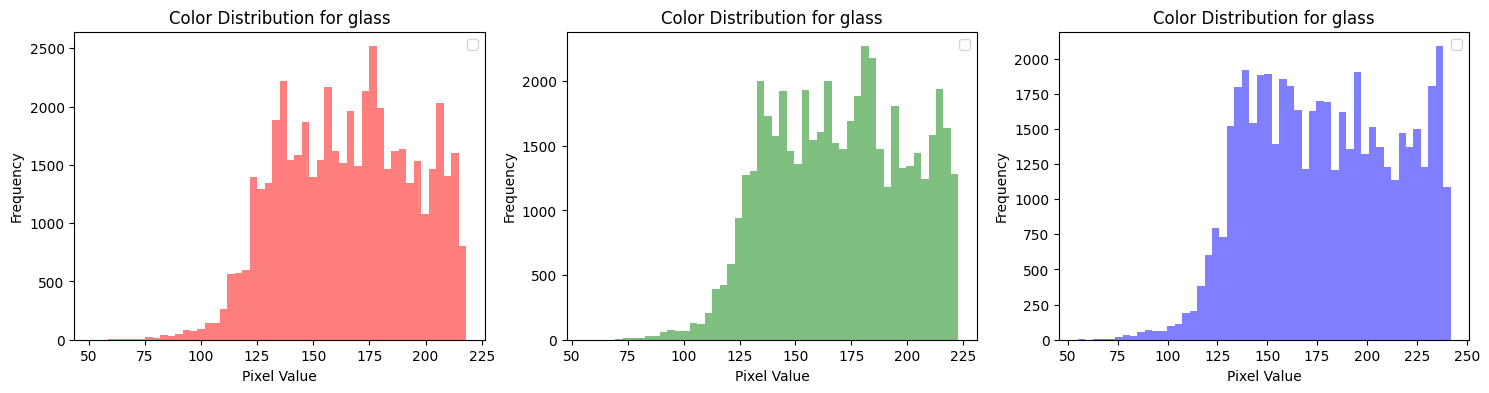

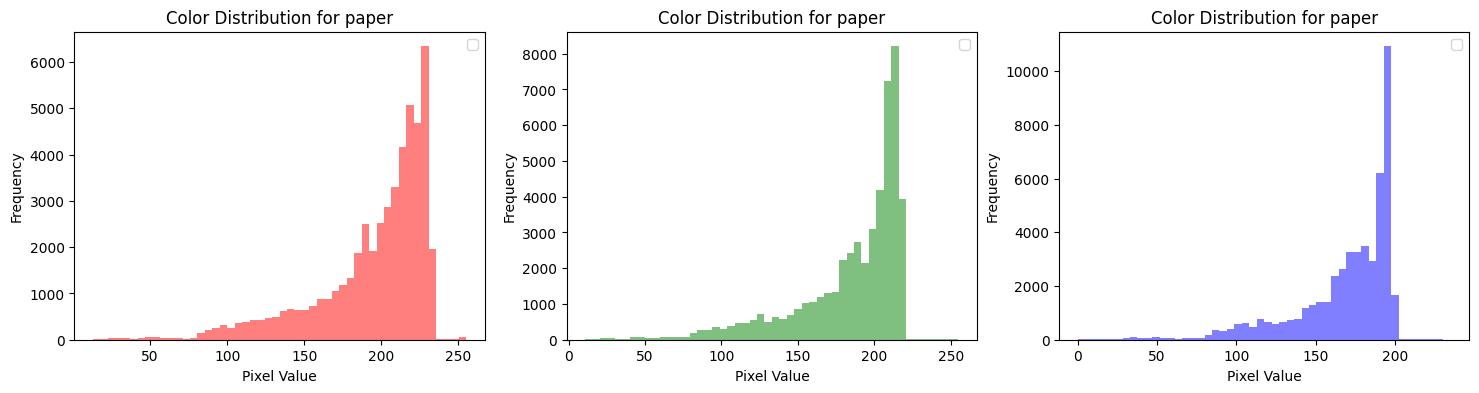

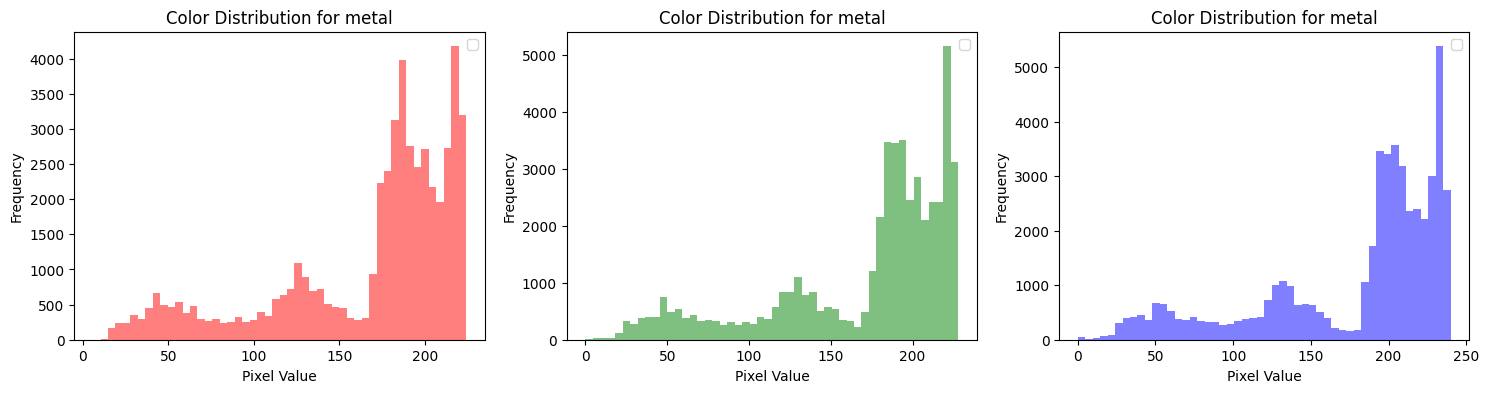

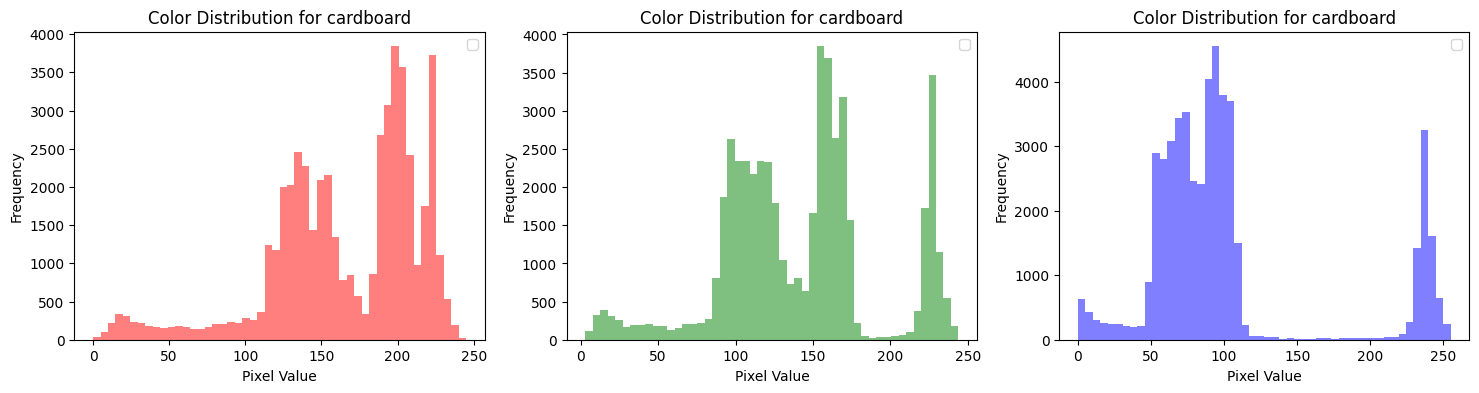

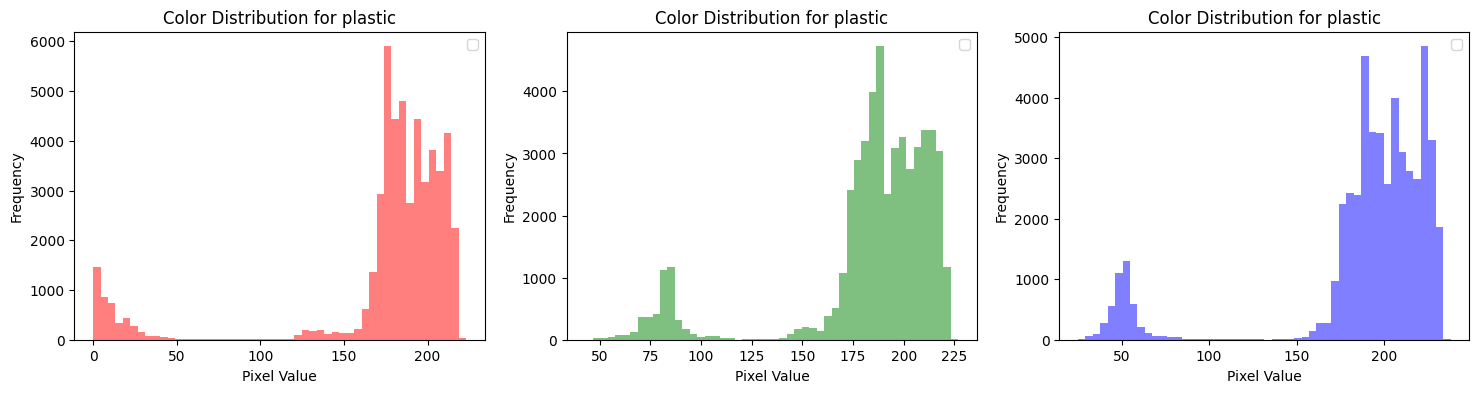

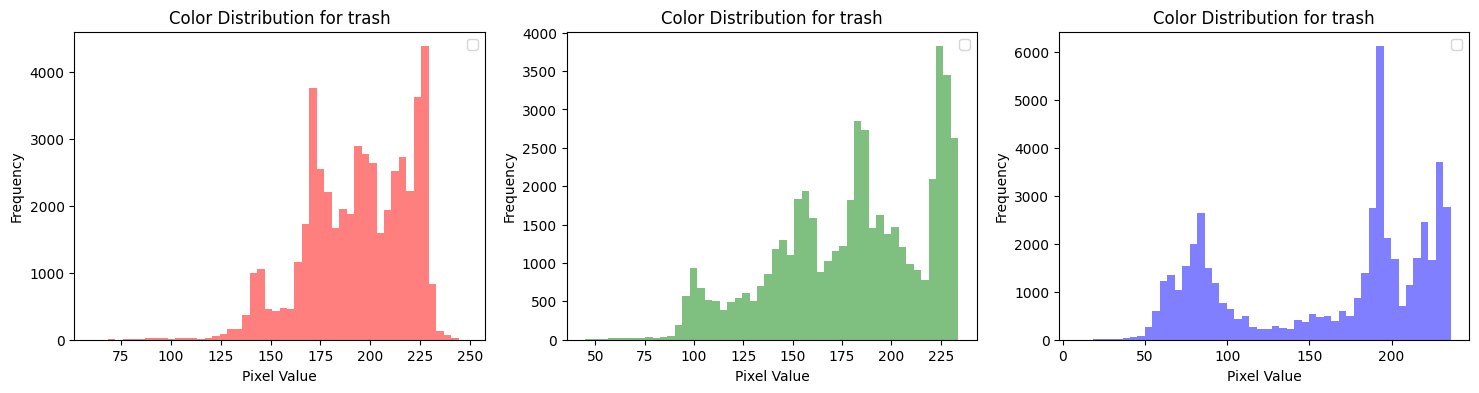

In [8]:
#Analyze pixel intensity or color distribution
col = ('red','green','blue')
class_names = data.class_names
ex = {}
for batch_img, batch_label in data.take(100):
    lbl = batch_label.numpy()
    class_name = class_names[lbl]
    if class_name not in ex:
        ex[class_name] = batch_img.numpy().astype('uint8')
    if len(ex) == len(class_names):
        break
for class_name,img in ex.items():
    plt.figure(figsize=(18,4))
    for i, color in enumerate(col):
        ax = plt.subplot(1,len(col),i+1)
        plt.hist(img[:,:,i].ravel(),bins=50,color = color,alpha = 0.5)
        plt.title(f"Color Distribution for {class_name}")
        plt.xlabel('Pixel Value')
        plt.ylabel('Frequency')
        plt.legend()
    plt.show()

In [9]:
#To split the train and val
train_df = tf.keras.utils.image_dataset_from_directory("Datasets/Garbage classification/Garbage classification",validation_split = 0.2,subset='training',seed = 123,image_size=(224,224),batch_size=32)
val = tf.keras.utils.image_dataset_from_directory("Datasets/Garbage classification/Garbage classification",validation_split = 0.2,subset='validation',seed = 123,image_size=(224,224),batch_size=32)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.


In [10]:
#Splitting the val into validation and test dataset
val_split = len(val) // 2
val_df = val.take(val_split)
test_df = val.skip(val_split)

In [11]:
print(len(train_df),len(val_df),len(test_df))

64 8 8


In [12]:
label_name = val.class_names

In [13]:
#To apply variations in the train dataset such that it prevents overfitting by having a more diversified (varied) examples in train set
data_augment = tf.keras.Sequential([tf.keras.layers.RandomFlip('horizontal'),tf.keras.layers.RandomRotation(0.1),tf.keras.layers.RandomZoom(0.2),tf.keras.layers.RandomContrast(0.2),tf.keras.layers.RandomBrightness(factor=0.2)])

In [14]:
labels = np.concatenate([y.numpy() for x,y in train_df])
print(labels[:30])

[4 0 2 0 0 3 3 3 2 3 1 1 3 3 3 0 2 2 4 3 4 4 1 2 3 3 0 4 2 2]


In [15]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
display(class_weights)
class_wt_dt = dict(enumerate(class_weights))
display(class_wt_dt)

array([1.053125  , 0.84673367, 1.01506024, 0.71702128, 0.85532995,
       3.12037037])

{0: np.float64(1.053125),
 1: np.float64(0.8467336683417085),
 2: np.float64(1.0150602409638554),
 3: np.float64(0.7170212765957447),
 4: np.float64(0.8553299492385786),
 5: np.float64(3.1203703703703702)}

In [16]:
for i,l in train_df.take(1):
    print(i.shape,l.shape,l[:10].numpy())
for i,l in val_df.take(1):
    print(i.shape,l.shape,l[:10].numpy())
display(class_wt_dt)
display(type(train_df))
display(type(val_df))

(32, 224, 224, 3) (32,) [1 1 1 5 3 1 1 0 4 0]
(32, 224, 224, 3) (32,) [3 3 1 0 0 3 3 3 4 2]


{0: np.float64(1.053125),
 1: np.float64(0.8467336683417085),
 2: np.float64(1.0150602409638554),
 3: np.float64(0.7170212765957447),
 4: np.float64(0.8553299492385786),
 5: np.float64(3.1203703703703702)}

tensorflow.python.data.ops.prefetch_op._PrefetchDataset

tensorflow.python.data.ops.take_op._TakeDataset

In [17]:
#Base CNN model
base_cnn = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(6,activation='softmax')
])
base_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)
base = base_cnn.fit(train_df,
    validation_data = val_df,
    epochs = 20,
    class_weight = class_wt_dt
)

Epoch 1/20


c:\Users\midst\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


64/64 ━━━━━━━━━━━━━━━━━━━━ 28s 419ms/step - accuracy: 0.2023 - loss: 43.7188 - val_accuracy: 0.2148 - val_loss: 1.7918
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 31s 477ms/step - accuracy: 0.1968 - loss: 1.7918 - val_accuracy: 0.2383 - val_loss: 1.7918
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 719ms/step - accuracy: 0.1469 - loss: 1.7918 - val_accuracy: 0.1875 - val_loss: 1.7918
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 31s 478ms/step - accuracy: 0.0732 - loss: 1.7918 - val_accuracy: 0.0586 - val_loss: 1.7919
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 60s 939ms/step - accuracy: 0.0534 - loss: 1.7918 - val_accuracy: 0.0469 - val_loss: 1.7920
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.0534 - loss: 1.7918 - val_accuracy: 0.0625 - val_loss: 1.7919
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.0534 - loss: 1.7918 - val_accuracy: 0.0625 - val_loss: 1.7919
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 237s 3s/step - accuracy: 0.0534 - loss: 1.7918 - val_accuracy: 0.0547 - v

In [18]:
backbones ={'ResNet50':(ResNet50(weights='imagenet',include_top=False,input_shape=(224,224,3)),resnet_preprocess),'MobileNetV2':(MobileNetV2(weights="imagenet",include_top=False,input_shape=(224,224,3)),mobilenet_preprocess),'EfficientNet50':(EfficientNetB0(weights='imagenet',include_top=False,input_shape=(224,224,3)),efficient_preprocess)}

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 46s 5us/step


Training ResNet50
Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 238s 3s/step - accuracy: 0.3966 - loss: 1.6556 - val_accuracy: 0.6914 - val_loss: 0.8973
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 191s 3s/step - accuracy: 0.6311 - loss: 1.0136 - val_accuracy: 0.7812 - val_loss: 0.6286
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 212s 3s/step - accuracy: 0.7097 - loss: 0.7905 - val_accuracy: 0.8086 - val_loss: 0.5645
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 205s 3s/step - accuracy: 0.7453 - loss: 0.7099 - val_accuracy: 0.8398 - val_loss: 0.4753
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 201s 3s/step - accuracy: 0.7765 - loss: 0.6354 - val_accuracy: 0.8633 - val_loss: 0.4386
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 198s 3s/step - accuracy: 0.7938 - loss: 0.5717 - val_accuracy: 0.8359 - val_loss: 0.4566
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 216s 3s/step - accuracy: 0.8185 - loss: 0.5168 - val_accuracy: 0.8594 - val_loss: 0.4098
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 211s 3s/step - accuracy: 0.8180 - loss: 0.5363 - val_ac

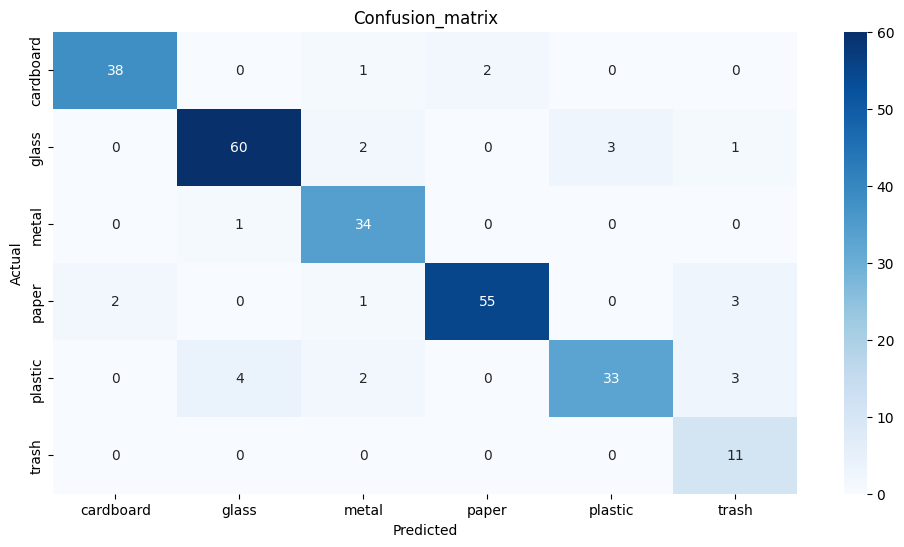

Training MobileNetV2
Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 49s 706ms/step - accuracy: 0.2878 - loss: 1.7835 - val_accuracy: 0.5469 - val_loss: 1.3036
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 40s 620ms/step - accuracy: 0.4906 - loss: 1.3268 - val_accuracy: 0.6406 - val_loss: 0.9973
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.5905 - loss: 1.1016 - val_accuracy: 0.7031 - val_loss: 0.8465
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.6489 - loss: 0.9620 - val_accuracy: 0.7305 - val_loss: 0.7453
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.6820 - loss: 0.8766 - val_accuracy: 0.7734 - val_loss: 0.6505
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 216s 3s/step - accuracy: 0.6919 - loss: 0.8221 - val_accuracy: 0.7969 - val_loss: 0.6097
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 37s 573ms/step - accuracy: 0.7364 - loss: 0.7358 - val_accuracy: 0.8047 - val_loss: 0.5664
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 39s 601ms/step - accuracy: 0.7409 - loss: 0.725

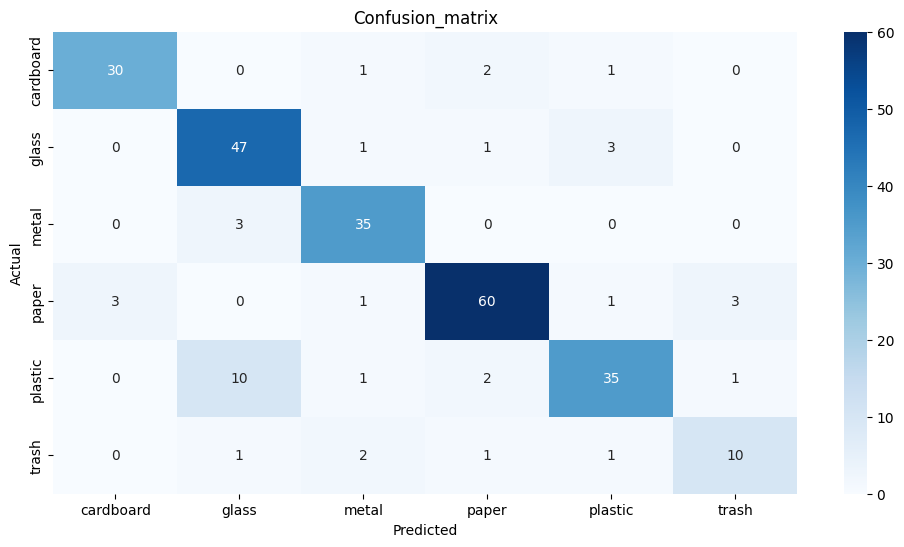

Training EfficientNet50
Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.3501 - loss: 1.6308 - val_accuracy: 0.6055 - val_loss: 1.2999
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 852ms/step - accuracy: 0.5851 - loss: 1.2132 - val_accuracy: 0.7422 - val_loss: 0.9245
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 836ms/step - accuracy: 0.6741 - loss: 0.9776 - val_accuracy: 0.8203 - val_loss: 0.6960
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.7141 - loss: 0.8304 - val_accuracy: 0.8086 - val_loss: 0.6724
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 64s 746ms/step - accuracy: 0.7468 - loss: 0.7459 - val_accuracy: 0.8438 - val_loss: 0.5741
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 50s 775ms/step - accuracy: 0.7774 - loss: 0.6667 - val_accuracy: 0.8711 - val_loss: 0.5305
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 51s 788ms/step - accuracy: 0.7903 - loss: 0.6184 - val_accuracy: 0.8398 - val_loss: 0.5311
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.7943 - loss: 0.

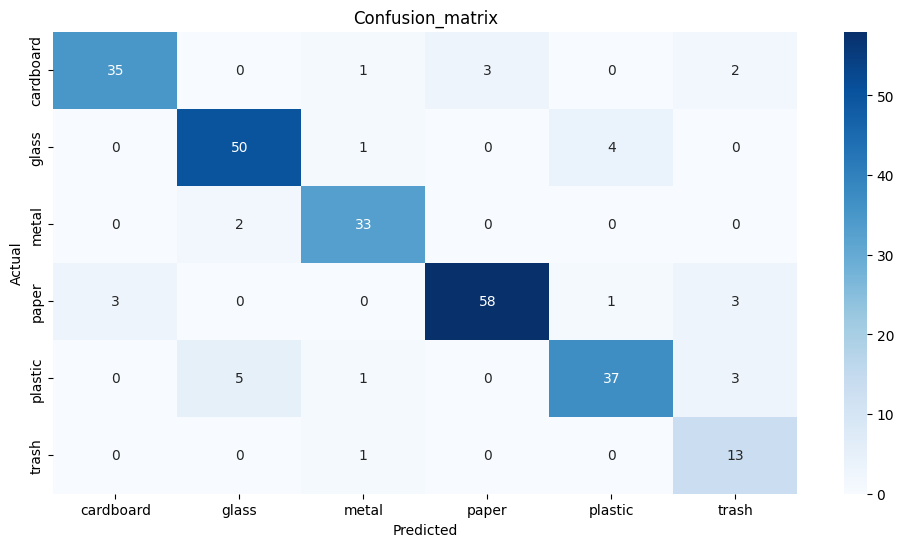

In [19]:
for name,(base_model,preprocess_fn) in backbones.items():
    base_model.trainable = False
    m = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128,activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(6,activation='softmax')])
    m.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss = 'sparse_categorical_crossentropy',
        metrics = ['accuracy']
    )
    #Preprocessing dataset
    train_df_prep = train_df.map(lambda x,y: (preprocess_fn(data_augment(x)),y))
    val_df_prep = val_df.map(lambda x,y:(preprocess_fn(x),y))
    test_df_prep = test_df.map(lambda x,y:(preprocess_fn(x),y))
    #Training a model
    print(f"Training {name}")
    final = m.fit(train_df_prep,validation_data=val_df_prep,epochs=20,class_weight=class_wt_dt)
    #Evaluation
    y_true,y_pred = [] , []
    for img,label in val_df_prep:
        pred = m.predict(img)
        y_true.extend(label.numpy())
        y_pred.extend(np.argmax(pred,axis=1))
    #Classification report
    print(f'Evaluation report {name}')
    print(classification_report(y_true,y_pred))
    #Visulations of misclassifications
    cm = confusion_matrix(y_true,y_pred)
    print(cm)
    plt.figure(figsize=(12,6))
    sns.heatmap(cm,annot=True,cmap='Blues',xticklabels = label_name,yticklabels=label_name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title('Confusion_matrix')
    plt.show()
    #save the model
    m.save(f"{name}_cnn.keras")

In [20]:
#Exporting the raw test dataset
import os
from PIL import Image
z = 0
#Export test images
export_dir = "Test"
for batch_i,(imgs,lbls) in enumerate(test_df):
    for j in range(imgs.shape[0]):
        img_array = imgs[j].numpy().astype('uint8')
        label_name = class_names[lbls[j].numpy()]
        label_dir = os.path.join(export_dir,label_name)
        os.makedirs(label_dir,exist_ok=True)
        pil_img = Image.fromarray(img_array)
        pil_img.save(os.path.join(label_dir,f"test_{z}.jpg"))
        z +=1

In [21]:
#Exported the raw train dataset
x = 0
export_dir = "Train"
os.path.join(export_dir)
for batch_i, (imgs,lbls) in enumerate(train_df):
    for j in range(imgs.shape[0]):
        image_array = imgs[j].numpy().astype('uint8')
        label_name = class_names[lbls[j].numpy()]
        label_dir=os.path.join(export_dir,label_name)
        os.makedirs(label_dir,exist_ok=True)
        pil_img = Image.fromarray(image_array)
        pil_img.save(os.path.join(label_dir,f"train_{x}.jpg"))
        x +=1

In [22]:
#Exporting the raw val dataset
y = 0
export_dir = "Val"
os.path.join(export_dir)
for batch_i, (imgs,lbls) in enumerate(val_df):
    for j in range(imgs.shape[0]):
        label_name=class_names[lbls[j].numpy()]
        image_array = imgs[j].numpy().astype('uint8')
        label_dir = os.path.join(export_dir,label_name)
        os.makedirs(label_dir,exist_ok=True)
        pil_img = Image.fromarray(image_array)
        pil_img.save(os.path.join(label_dir,f"val_{y}.jpg"))
        y += 1